In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os


# Better visuals
sns.set_theme(style="whitegrid")

In [4]:
sys.path.append(os.path.abspath('..'))
from src.data_loader import load_data
from src.data_cleaning import clean_data
from src.feature_engineering import add_features

df = load_data('../data/raw/telco_churn.csv')
df = clean_data(df)
df = add_features(df)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CLV,TenureGroup,Revenue
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85,0-12 Months,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,1936.30,24-48 Months,56.95
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,107.70,0-12 Months,53.85
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1903.50,24-48 Months,42.30
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,141.40,0-12 Months,70.70


In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7032 non-null   category
 1   gender            7032 non-null   category
 2   SeniorCitizen     7032 non-null   category
 3   Partner           7032 non-null   category
 4   Dependents        7032 non-null   category
 5   tenure            7032 non-null   int64   
 6   PhoneService      7032 non-null   category
 7   MultipleLines     7032 non-null   category
 8   InternetService   7032 non-null   category
 9   OnlineSecurity    7032 non-null   category
 10  OnlineBackup      7032 non-null   category
 11  DeviceProtection  7032 non-null   category
 12  TechSupport       7032 non-null   category
 13  StreamingTV       7032 non-null   category
 14  StreamingMovies   7032 non-null   category
 15  Contract          7032 non-null   category
 16  PaperlessBilling  7032 non-null   catego

,tenure,MonthlyCharges,TotalCharges,CLV,Revenue
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,2283.147248,64.798208
std,24.545260,30.085974,2266.771362,2264.703327,30.085974
min,1.000000,18.250000,18.800000,18.800000,18.250000
25%,9.000000,35.587500,401.450000,397.800000,35.587500
50%,29.000000,70.350000,1397.475000,1394.575000,70.350000
75%,55.000000,89.862500,3794.737500,3791.250000,89.862500
max,72.000000,118.750000,8684.800000,8550.000000,118.750000


In [6]:
total_customers = len(df)
churned_customers = df[df['Churn'] == 'Yes'].shape[0]
churn_rate = churned_customers / total_customers

total_revenue = df['MonthlyCharges'].sum()
revenue_loss = df[df['Churn'] == 'Yes']['MonthlyCharges'].sum()

print(f"Total Customers: {total_customers}")
print(f"Churn Rate: {round(churn_rate*100,2)}%")
print(f"Total Revenue: {round(total_revenue,2)}")
print(f"Revenue Loss: {round(revenue_loss,2)}")

Total Customers: 7032
Churn Rate: 26.58%
Total Revenue: 455661.0
Revenue Loss: 139130.85


In [7]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


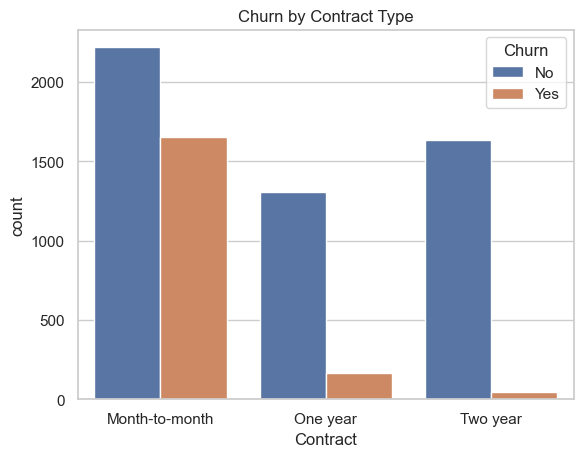

In [8]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Churn by Contract Type")
plt.show()

In [9]:
payment_churn = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack()
payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832685,0.167315
Credit card (automatic),0.847469,0.152531
Electronic check,0.547146,0.452854
Mailed check,0.807980,0.192020


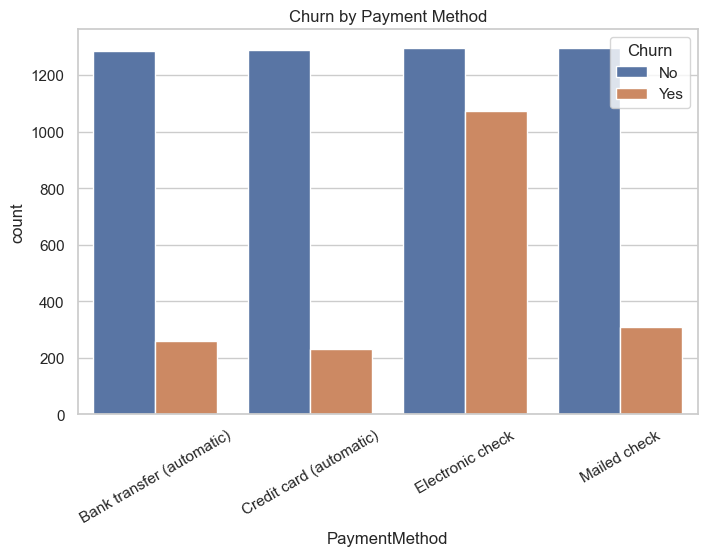

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.xticks(rotation=30)
plt.title("Churn by Payment Method")
plt.show()

In [11]:
tenure_revenue = df.groupby('TenureGroup')['MonthlyCharges'].mean()
tenure_revenue

TenureGroup
0-12 Months     56.172023
12-24 Months    61.357275
24-48 Months    65.930552
48+ Months      73.945377
Name: MonthlyCharges, dtype: float64

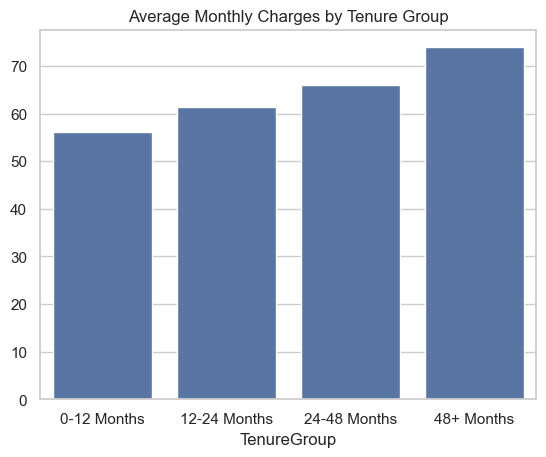

In [12]:
sns.barplot(x=tenure_revenue.index, y=tenure_revenue.values)
plt.title("Average Monthly Charges by Tenure Group")
plt.show()

In [13]:
df[['customerID', 'CLV', 'Churn']].sort_values(by='CLV', ascending=False).head(10)

,customerID,CLV,Churn
4586,7569-NMZYQ,8550.00,No
6118,9924-JPRMC,8510.40,No
4610,2889-FPWRM,8481.60,Yes
3205,3810-DVDQQ,8467.20,No
6768,9739-JLPQJ,8460.00,No
4155,6904-JLBGY,8449.20,No
2368,6650-BWFRT,8434.80,No
2115,8984-HPEMB,8424.15,No
5347,9788-HNGUT,8420.40,No
2025,1488-PBLJN,8413.20,No


In [14]:
high_value_threshold = df['CLV'].mean()

high_value_churn = df[
    (df['Churn'] == 'Yes') & (df['CLV'] > high_value_threshold)
]

high_value_churn[['customerID', 'CLV', 'Contract']].head()

,customerID,CLV,Contract
8,7892-POOKP,2934.40,Month-to-month
13,0280-XJGEX,5081.30,Month-to-month
26,6467-CHFZW,4669.45,Month-to-month
38,5380-WJKOV,3615.90,Month-to-month
99,4598-XLKNJ,2462.50,Month-to-month


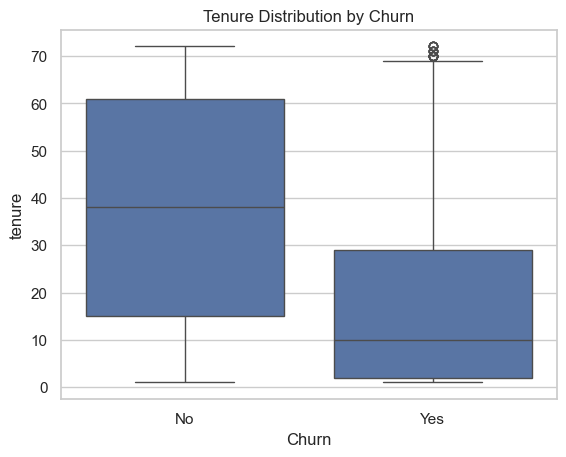

In [15]:
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title("Tenure Distribution by Churn")
plt.show()

In [16]:
print("KEY INSIGHTS:")
print("1. Month-to-month contracts drive highest churn.")
print("2. Electronic check users show higher churn behavior.")
print("3. Early-tenure customers are more likely to churn.")
print("4. High-value customers are also at risk → revenue leakage.")
print("5. Long-term customers contribute stable revenue.")

KEY INSIGHTS:
1. Month-to-month contracts drive highest churn.
2. Electronic check users show higher churn behavior.
3. Early-tenure customers are more likely to churn.
4. High-value customers are also at risk → revenue leakage.
5. Long-term customers contribute stable revenue.
